# Morpho Risk Case Study — Exploratory Analysis
## xUSD / deUSD / sdeUSD Depeg — November 2025

**Purpose:** data quality checks → answer dashboard questions → surface the debrief narratives.

| Section | Question |
|---------|----------|
| 0 | Setup & data loading |
| 1 | Data quality checks |
| 2 | Q1–2: Exposure & losses |
| 3 | Q3–4: Early exits & curator actions |
| 4 | Q5: Vault liquidity evolution |
| 5 | Debrief — why liquidations failed |
| 6 | Debrief — shared liquidity risk |


## 0 · Setup & data loading

In [1]:
import json
import math
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.float_format", "{:,.2f}".format)

DATA = Path("data")
NOV_START = datetime(2025, 11, 1, tzinfo=timezone.utc)
NOV_END   = datetime(2025, 11, 30, 23, 59, 59, tzinfo=timezone.utc)

def load(name):
    return json.loads((DATA / name).read_text())

def ts_to_dt(ts):
    return datetime.fromtimestamp(int(ts), tz=timezone.utc)

def xy_to_df(series, value_col="value"):
    rows = [{"date": ts_to_dt(p["x"]), value_col: p["y"]} for p in series if p.get("y") is not None]
    if not rows:
        return pd.DataFrame(columns=["date", value_col])
    return pd.DataFrame(rows).sort_values("date").reset_index(drop=True)

# ── load all files ─────────────────────────────────────────────────────────
assets      = load("incident_assets.json")
markets     = load("markets.json")
liq_txs     = load("liquidations.json")
liq_summary = load("liquidation_summary.json")
hist_mkts   = load("historical_markets.json")
hist_vaults = load("historical_vaults.json")
prices      = load("collateral_prices.json")
positions   = load("market_top_positions.json")
activity    = load("market_activity_tx.json")
mm_activity = load("metamorpho_activity.json")
v2_top      = load("vaults_v2_top.json")
v1_incident = load("vaults_v1_incident.json")
supply_vaults = load("supplying_vaults.json")
errors      = load("etl_extended_errors.json")

print(f"Assets:            {len(assets)}")
print(f"Markets:           {len(markets)}")
print(f"Liquidation txs:   {len(liq_txs)}")
print(f"Historical markets:{len(hist_mkts)}")
print(f"Historical vaults: {len(hist_vaults)}")
print(f"Price series:      {len(prices)}")
print(f"ETL errors:        {len(errors)}")


Assets:            3
Markets:           11
Liquidation txs:   2
Historical markets:11
Historical vaults: 2
Price series:      3
ETL errors:        0


## 1 · Data quality checks

In [2]:
# 1a — incident assets table
df_assets = pd.DataFrame([
    {"symbol": a["symbol"], "address": a["address"], "decimals": a["decimals"], "chain_id": a["chain"]["id"]}
    for a in assets
])
print("=== Incident collateral assets ===")
display(df_assets)


=== Incident collateral assets ===


,symbol,address,decimals,chain_id
0,xUSD,0xE2Fc85BfB48C4cF147921fBE110cf92Ef9f26F94,6,1
1,sdeUSD,0x5C5b196aBE0d54485975D1Ec29617D42D9198326,18,1
2,deUSD,0x15700B564Ca08D9439C58cA5053166E8317aa138,18,1


In [3]:
# 1b — market snapshot integrity
df_mkts = pd.json_normalize(markets)
df_mkts["lltv_pct"] = df_mkts["lltv"].astype(float) / 1e18 * 100
df_mkts["chain_id"] = df_mkts["loanAsset.chain.id"]
df_mkts["label"] = df_mkts["collateralAsset.symbol"] + " / " + df_mkts["loanAsset.symbol"]
df_mkts["borrow_usd"] = pd.to_numeric(df_mkts["state.borrowAssetsUsd"], errors="coerce")
df_mkts["supply_usd"] = pd.to_numeric(df_mkts["state.supplyAssetsUsd"], errors="coerce")
df_mkts["liquidity_usd"] = pd.to_numeric(df_mkts["state.liquidityAssetsUsd"], errors="coerce")
df_mkts["utilization"] = pd.to_numeric(df_mkts["state.utilization"], errors="coerce")

print(f"Total markets: {len(df_mkts)}")
print(f"Markets with borrow > $1k: {(df_mkts.borrow_usd > 1_000).sum()}")
print(f"Markets at 100% utilization: {(df_mkts.utilization >= 0.9999).sum()}")
print(f"Markets with collateralAssetsUsd null: {df_mkts['state.collateralAssetsUsd'].isna().sum()}")
print()
display(df_mkts[["uniqueKey","label","lltv_pct","borrow_usd","liquidity_usd","utilization","chain_id"]].sort_values("borrow_usd", ascending=False).reset_index(drop=True))


Total markets: 11
Markets with borrow > $1k: 2
Markets at 100% utilization: 2
Markets with collateralAssetsUsd null: 11



,uniqueKey,label,lltv_pct,borrow_usd,liquidity_usd,utilization,chain_id
0,0x0f9563442d64ab3bd3bcb27058db0b0d4046a4c46f0acd811dacae9551d2b129,sdeUSD / USDC,91.50,"130,058,055.84",0.00,1.00,1
1,0xbd1ad3b968f5f0552dbd8cf1989a62881407c5cccf9e49fb3657c8731caf0c1f,deUSD / USDC,86.00,"20,585.17",0.00,1.00,1
2,0x7182fd5e9c6a77156d6ac024d1e462b9ca3a85463961957a5e3d367c9ce44b84,deUSD / USDC,86.00,7.78,2.30,0.77,1
3,0x1c6f0822b996c86b2cace788cc265beb4f84585456aba8f424c710e67116b93d,deUSD / USDC,91.50,0.95,0.10,0.90,1
4,0x39fe55e5102beac5fb3caff54142f26250b97dcdb5bea6122818c7760f38b331,xUSD / USDC,77.00,0.10,0.01,0.90,1
5,0x226a59cd57c8c75ddaf440e2be68b92dbf8dafaed6a715290d0789d1fdc521c2,deUSD / USDC,86.00,0.00,0.00,0.00,1
6,0x46b46943e982bf04f7b07ff37c95b539e35ccd8cf93c331cd9659398aa8f7bee,sdeUSD / USDC,91.50,0.00,0.00,0.00,1
7,0x7527be7772eb6e2e6bd9a5a9cc83dcd67fd1c9e6103d09868d0308eb3b70af2c,deUSD / sUSDS,91.50,0.00,0.00,0.00,1
8,0xc05394d0261ed1c3c1af310007fdc4e64b3bcf650822b70526763fefc64b729e,xUSD / USDC,77.00,0.00,0.10,0.00,1
9,0xe31af163f7ea13aa0d7719f3d865a8795a7973d9ff54ff418431718ad16f5c2d,sdeUSD / USDC,91.50,0.00,0.00,0.00,1


In [4]:
# 1c — warnings summary
warning_rows = []
for m in markets:
    for w in m.get("warnings", []):
        warning_rows.append({
            "uniqueKey": m["uniqueKey"],
            "collateral": m["collateralAsset"]["symbol"],
            "loan": m["loanAsset"]["symbol"],
            "type": w["type"],
            "level": w["level"],
        })
df_warn = pd.DataFrame(warning_rows)
print("=== Warning counts ===")
display(df_warn.groupby(["type","level"]).size().rename("count").reset_index().sort_values("count", ascending=False))


=== Warning counts ===


,type,level,count
2,no_whitelisted_allocation,RED,11
3,not_whitelisted,YELLOW,11
4,unrecognized_collateral_asset,YELLOW,2
0,bad_debt_unrealized,RED,1
1,custom,RED,1


In [5]:
# 1d — collateral price coverage (null / sparse check)
price_qc = []
for series in prices:
    pts = series.get("historicalPriceUsd", [])
    non_null = [p for p in pts if p["y"] is not None]
    price_qc.append({
        "symbol": series["symbol"],
        "address": series["address"],
        "chain_id": series["chainId"],
        "total_days": len(pts),
        "non_null_days": len(non_null),
        "coverage_pct": round(len(non_null)/len(pts)*100, 1) if pts else 0,
        "price_first": non_null[-1]["y"] if non_null else None,
        "price_last":  non_null[0]["y"] if non_null else None,
    })
df_prices_qc = pd.DataFrame(price_qc)
print("=== Collateral price coverage (Morpho oracle / price feed) ===")
display(df_prices_qc)


=== Collateral price coverage (Morpho oracle / price feed) ===


,symbol,address,chain_id,total_days,non_null_days,coverage_pct,price_first,price_last
0,xUSD,0xE2Fc85BfB48C4cF147921fBE110cf92Ef9f26F94,1,30,30,100.00,1.26,0.06
1,sdeUSD,0x5C5b196aBE0d54485975D1Ec29617D42D9198326,1,30,30,100.00,1.07,0.00
2,deUSD,0x15700B564Ca08D9439C58cA5053166E8317aa138,1,30,14,46.70,1.00,0.00


In [6]:
# 1e — historical market data completeness
hist_qc = []
for m in hist_mkts:
    for field in ["borrowAssetsUsd","supplyAssetsUsd","liquidityAssetsUsd","collateralAssetsUsd","utilization"]:
        pts = m["historicalState"].get(field, [])
        non_null = [p for p in pts if p["y"] is not None]
        hist_qc.append({
            "market": m["collateralAsset"]["symbol"] + "/" + m["loanAsset"]["symbol"],
            "uniqueKey_short": m["uniqueKey"][:10] + "...",
            "field": field,
            "days": len(pts),
            "non_null": len(non_null),
        })
df_hist_qc = pd.DataFrame(hist_qc)
summary = df_hist_qc.groupby(["market","field"])[["days","non_null"]].sum().reset_index()
print("=== Historical data point counts per market-field ===")
display(summary.pivot(index="market", columns="field", values="non_null").fillna(0).astype(int))


=== Historical data point counts per market-field ===


field,borrowAssetsUsd,collateralAssetsUsd,liquidityAssetsUsd,supplyAssetsUsd,utilization
market,,,,,
deUSD/USDC,120,120,120,120,120
deUSD/sUSDS,60,60,60,60,60
sdeUSD/USDC,90,90,90,90,90
xUSD/USDC,60,60,60,60,60


In [7]:
# 1f — ETL error log (should be empty)
if errors:
    display(pd.DataFrame(errors))
else:
    print("✓ No ETL errors recorded")


✓ No ETL errors recorded


## 2 · Q1–2: Exposure & losses

> *Which markets and vaults were exposed? What were the bad debt amounts?*


In [8]:
# 2a — Market exposure summary table
print("=== Market exposure at snapshot ===")
exp = df_mkts[df_mkts.borrow_usd > 0][[
    "label","uniqueKey","lltv_pct","borrow_usd","supply_usd","liquidity_usd","utilization","chain_id"
]].copy()
exp = exp.sort_values("borrow_usd", ascending=False).reset_index(drop=True)
exp["utilization_%"] = (exp["utilization"]*100).round(2)
exp["liquidity_usd_fmt"] = exp["liquidity_usd"].map(lambda x: f"${x:,.0f}")
display(exp[["label","lltv_pct","borrow_usd","liquidity_usd_fmt","utilization_%","chain_id"]])


=== Market exposure at snapshot ===


,label,lltv_pct,borrow_usd,liquidity_usd_fmt,utilization_%,chain_id
0,sdeUSD / USDC,91.50,"130,058,055.84",$0,100.00,1
1,deUSD / USDC,86.00,"20,585.17",$0,100.00,1
2,deUSD / USDC,86.00,7.78,$2,77.16,1
3,deUSD / USDC,91.50,0.95,$0,90.44,1
4,xUSD / USDC,77.00,0.10,$0,89.72,1


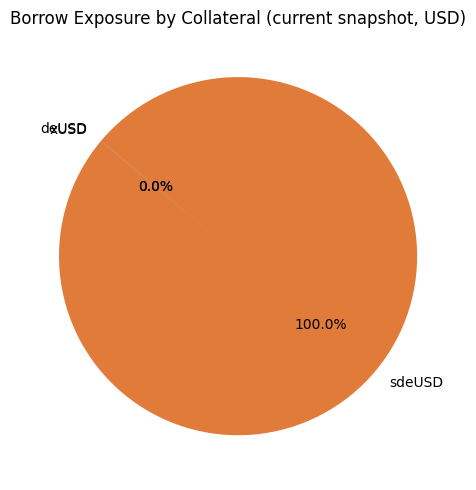

Total borrow across incident markets: $130,078,650


In [9]:
# 2b — Pie: borrow exposure by collateral type
borrow_by_coll = df_mkts.groupby("collateralAsset.symbol")["borrow_usd"].sum().sort_values(ascending=False)
borrow_by_coll = borrow_by_coll[borrow_by_coll > 0]

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    borrow_by_coll.values,
    labels=borrow_by_coll.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#e07b39","#5b8db8","#6abf69","#c36"],
)
ax.set_title("Borrow Exposure by Collateral (current snapshot, USD)")
plt.tight_layout()
plt.show()
total = borrow_by_coll.sum()
print(f"Total borrow across incident markets: ${total:,.0f}")


In [10]:
# 2c — Top borrowers per major market
print("=== Top positions (by borrow USD) ===")
for uk, pos_list in positions.items():
    mkt = next((m for m in markets if m["uniqueKey"]==uk), {})
    label = f"{mkt.get('collateralAsset',{}).get('symbol','?')}/{mkt.get('loanAsset',{}).get('symbol','?')}"
    rows = []
    for p in pos_list:
        rows.append({
            "user": p["user"]["address"][:12]+"...",
            "borrow_usd": float(p["state"].get("borrowAssetsUsd") or 0),
        })
    if not rows:
        print(f"\n[{label}] {uk[:14]}... — no positions")
        continue
    df_p = pd.DataFrame(rows, columns=["user","borrow_usd"]).sort_values("borrow_usd", ascending=False)
    print(f"\n[{label}] {uk[:14]}...")
    display(df_p.reset_index(drop=True))


=== Top positions (by borrow USD) ===

[sdeUSD/USDC] 0x0f9563442d64...


,user,borrow_usd
0,0x1597E4B7cF...,"130,037,398.08"
1,0x46566dA2ac...,"12,957.46"
2,0xC610fb0F2A...,"7,655.34"



[deUSD/USDC] 0xbd1ad3b968f5...


,user,borrow_usd
0,0x0C9464a8e7...,"17,551.76"
1,0xDE2BbA83ca...,896.26
2,0xB2AE1e7741...,709.09



[deUSD/USDC] 0x7182fd5e9c6a...


...


[deUSD/USDC] 0x226a59cd57c8... — no positions

[sdeUSD/USDC] 0x46b46943e982...


,user,borrow_usd
0,0x0000000000...,0.00
1,0x06590Fef20...,0.00



[deUSD/sUSDS] 0x7527be7772eb... — no positions

[xUSD/USDC] 0xc05394d0261e...


,user,borrow_usd
0,0x0000000000...,0.00
1,0x594c5eE5a3...,0.00



[sdeUSD/USDC] 0xe31af163f7ea... — no positions

[deUSD/sUSDS] 0xeb0403429dab... — no positions


In [11]:
# 2d — Bad debt from liquidation summary
print("=== Liquidation summary (Nov 2025 window) ===")
total_bad  = liq_summary["totals"]["bad_debt_usd"]
total_txs  = liq_summary["totals"]["liquidation_txs"]
print(f"  Liquidation transactions: {total_txs}")
print(f"  Total bad debt recorded:  ${total_bad:,.4f}")
print()

bymarket = []
for uk, row in liq_summary["byMarket"].items():
    mkt = next((m for m in markets if m["uniqueKey"]==uk), {})
    bymarket.append({
        "market": mkt.get("collateralAsset",{}).get("symbol","?") + "/" + mkt.get("loanAsset",{}).get("symbol","?"),
        "uniqueKey_short": uk[:14]+"...",
        "count": row["liquidation_count"],
        "bad_debt_usd": row["bad_debt_usd"],
        "repaid_usd": row["repaid_usd"],
        "seized_usd": row["seized_usd"],
    })
df_bymarket = pd.DataFrame(bymarket)
display(df_bymarket)


=== Liquidation summary (Nov 2025 window) ===
  Liquidation transactions: 2
  Total bad debt recorded:  $0.0000



,market,uniqueKey_short,count,bad_debt_usd,repaid_usd,seized_usd
0,sdeUSD/USDC,0x0f9563442d64...,2,0.00,1.00,0.00


In [12]:
# 2e — Individual liquidation events
liq_rows = []
for tx in liq_txs:
    d = tx.get("data", {})
    liq_rows.append({
        "date": ts_to_dt(tx["timestamp"]).strftime("%Y-%m-%d %H:%M"),
        "block": tx["blockNumber"],
        "market_short": d.get("market", {}).get("uniqueKey","?")[:14]+"...",
        "liquidator": d.get("liquidator","?")[:14]+"...",
        "repaid_usd": d.get("repaidAssetsUsd", 0),
        "seized_usd": d.get("seizedAssetsUsd", 0),
        "bad_debt_usd": d.get("badDebtAssetsUsd", 0),
    })
df_liq = pd.DataFrame(liq_rows)
print("=== Individual liquidation events ===")
display(df_liq)


=== Individual liquidation events ===


,date,block,market_short,liquidator,repaid_usd,seized_usd,bad_debt_usd
0,2025-11-26 16:25,23884090,0x0f9563442d64...,0x41615c2FB0Db...,1.00,0.00,0
1,2025-11-20 21:16,23842870,0x0f9563442d64...,0x80C6C6438A43...,0.00,0.00,0


In [13]:
# 2f — Vault exposure: V1 vaults with incident market allocation
if v1_incident:
    df_v1 = pd.DataFrame([{
        "name": v.get("name","?"),
        "address": v["address"][:14]+"...",
        "chain": v.get("chain",{}).get("network","?"),
        "tvl_usd": v.get("totalAssetsUsd"),
        "matched_markets": len(v.get("matchingMarketUniqueKeys",[])),
    } for v in v1_incident])
    print("=== V1 vaults with incident market allocation ===")
    display(df_v1)
else:
    print("No V1 vaults found with allocations to incident markets on chain 1.")
    print("(This is meaningful — these markets had zero whitelisted vault allocation at snapshot time.)")


No V1 vaults found with allocations to incident markets on chain 1.
(This is meaningful — these markets had zero whitelisted vault allocation at snapshot time.)


## 3 · Q3–4: Early exits & curator actions

> *Were curators exposed earlier but exited? What actions did they take?*


In [14]:
# 3a — Market activity timeline: borrow/repay/supply/withdraw per market
for uk, txs in activity.items():
    if not txs:
        continue
    mkt = next((m for m in markets if m["uniqueKey"]==uk), {})
    label = f"{mkt.get('collateralAsset',{}).get('symbol','?')}/{mkt.get('loanAsset',{}).get('symbol','?')}"

    df_act = pd.DataFrame([{
        "date": ts_to_dt(t["timestamp"]),
        "type": t["type"],
        "user": t["user"]["address"][:10]+"...",
    } for t in txs])

    type_counts = df_act["type"].value_counts()
    print(f"\n[{label}] activity breakdown (nov 2025 window, capped):")
    display(type_counts)



[sdeUSD/USDC] activity breakdown (nov 2025 window, capped):


type
MarketWithdraw    8
MarketSupply      7
Name: count, dtype: int64


[deUSD/USDC] activity breakdown (nov 2025 window, capped):


type
MarketSupplyCollateral      7
MarketWithdrawCollateral    4
MarketBorrow                3
MarketRepay                 1
Name: count, dtype: int64

In [15]:
# 3b — MetaMorpho vault activity (deposits/withdraws)
mm_rows = []
for vault_addr, txs in mm_activity.items():
    for t in txs:
        mm_rows.append({
            "vault": vault_addr[:14]+"...",
            "date": ts_to_dt(t["timestamp"]).strftime("%Y-%m-%d"),
            "type": t["type"],
            "user": t["user"]["address"][:12]+"...",
        })
if mm_rows:
    df_mm = pd.DataFrame(mm_rows)
    print("=== MetaMorpho vault flows (incident vaults, nov 2025) ===")
    display(df_mm.groupby(["vault","type"]).size().rename("count").reset_index())
else:
    print("No MetaMorpho activity found in window for incident vaults.")
    print("Likely confirms no vault-level deposits/withdraws during November 2025 (markets had no whitelisted allocation).")


No MetaMorpho activity found in window for incident vaults.
Likely confirms no vault-level deposits/withdraws during November 2025 (markets had no whitelisted allocation).


In [16]:
# 3c — Supplying vaults per market (any curator-managed vault currently supplying)
print("=== Vaults supplying to incident markets (current snapshot) ===")
for uk, svs in supply_vaults.items():
    mkt = next((m for m in markets if m["uniqueKey"]==uk), {})
    label = f"{mkt.get('collateralAsset',{}).get('symbol','?')}/{mkt.get('loanAsset',{}).get('symbol','?')}"
    if svs:
        print(f"\n[{label}]")
        for sv in svs:
            print(f"  {sv.get('name','?')} — {sv['address'][:14]}...")
    else:
        print(f"[{label}] — no supplying vaults (all supply is from direct borrowers / isolated)")


=== Vaults supplying to incident markets (current snapshot) ===
[sdeUSD/USDC] — no supplying vaults (all supply is from direct borrowers / isolated)
[deUSD/USDC] — no supplying vaults (all supply is from direct borrowers / isolated)
[deUSD/USDC] — no supplying vaults (all supply is from direct borrowers / isolated)
[deUSD/USDC] — no supplying vaults (all supply is from direct borrowers / isolated)
[xUSD/USDC] — no supplying vaults (all supply is from direct borrowers / isolated)
[deUSD/USDC] — no supplying vaults (all supply is from direct borrowers / isolated)
[sdeUSD/USDC] — no supplying vaults (all supply is from direct borrowers / isolated)
[deUSD/sUSDS] — no supplying vaults (all supply is from direct borrowers / isolated)
[xUSD/USDC] — no supplying vaults (all supply is from direct borrowers / isolated)
[sdeUSD/USDC] — no supplying vaults (all supply is from direct borrowers / isolated)
[deUSD/sUSDS] — no supplying vaults (all supply is from direct borrowers / isolated)


In [17]:
# 3d — Top V2 vaults (context: which curators manage the largest vaults on Morpho)
df_v2 = pd.DataFrame([{
    "name": v.get("name","?"),
    "symbol": v.get("symbol","?"),
    "chain": v.get("chain",{}).get("network","?"),
    "tvl_usd_m": round(v.get("totalAssetsUsd",0)/1e6, 2),
    "liquidity_usd_m": round(v.get("liquidityUsd",0)/1e6, 2),
    "n_curators": sum(len(c.get("addresses",[])) for c in v.get("curators",{}).get("items",[])),
} for v in v2_top])
print("=== Top Morpho V2 vaults (TVL context) ===")
display(df_v2.sort_values("tvl_usd_m", ascending=False).reset_index(drop=True))


=== Top Morpho V2 vaults (TVL context) ===


,name,symbol,chain,tvl_usd_m,liquidity_usd_m,n_curators
0,Sentora PYUSD Main,senPYUSDmain,Ethereum,276.67,97.25,2
1,Sentora RLUSD Main,senRLUSDv2,Ethereum,130.88,22.41,2


## 4 · Q5: Vault liquidity evolution

> *How did liquidity evolve? Which markets/vaults were most impacted?*


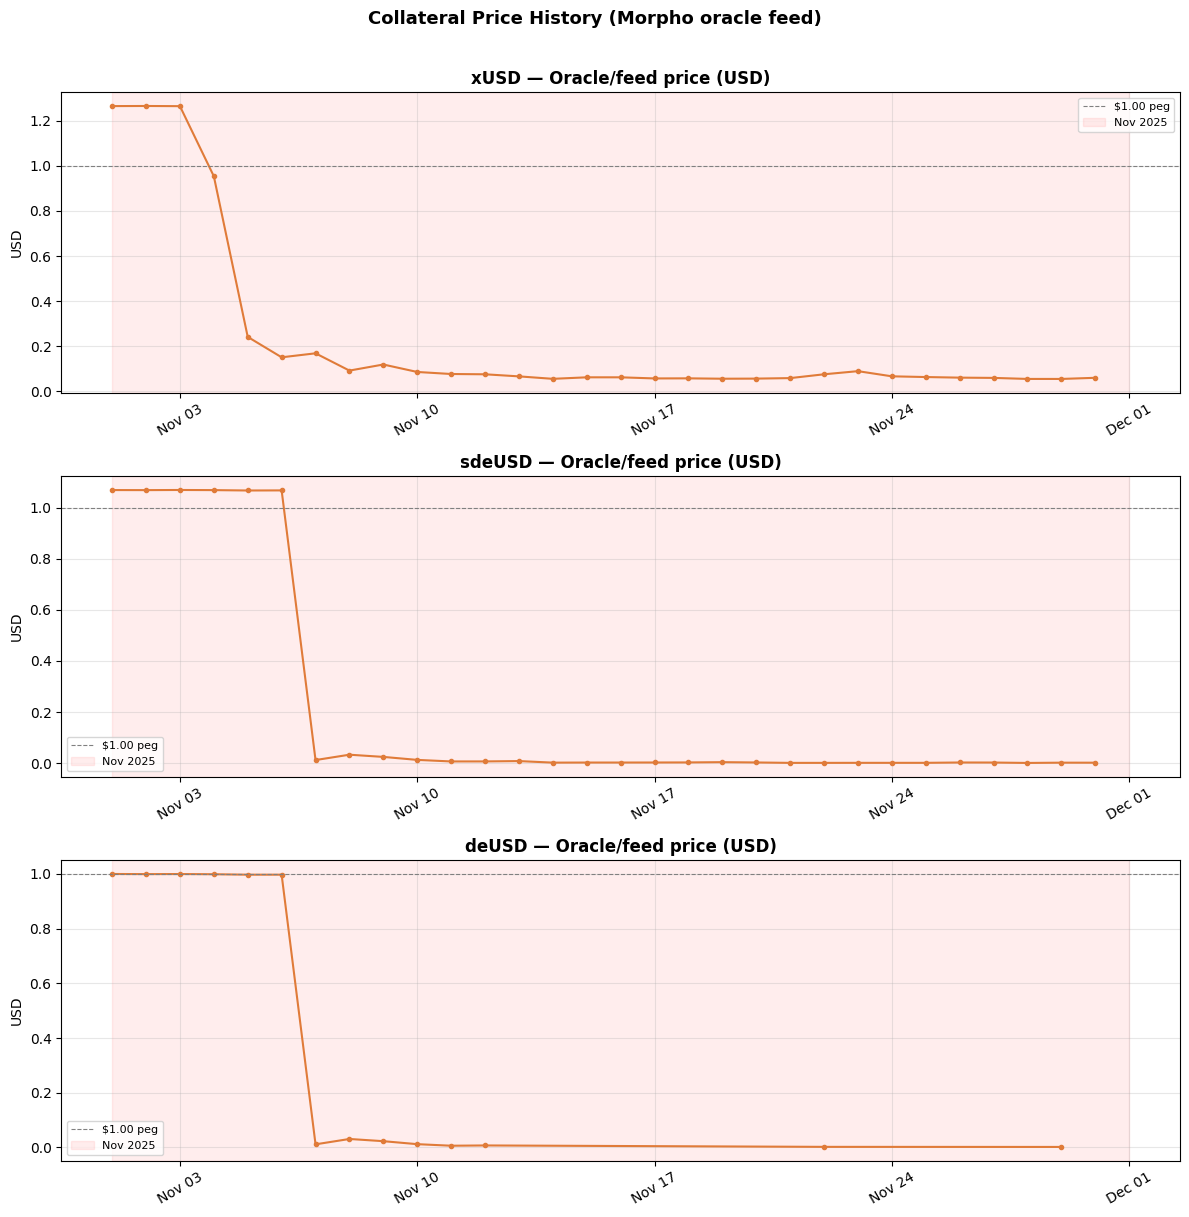

In [18]:
# 4a — Collateral price history: depeg visualised
fig, axes = plt.subplots(len(prices), 1, figsize=(12, 4*len(prices)), squeeze=False)
for i, series in enumerate(prices):
    ax = axes[i][0]
    df_p = xy_to_df(series.get("historicalPriceUsd",[]), "price_usd")
    if df_p.empty:
        ax.set_title(f"{series['symbol']} — no price data")
        continue
    ax.plot(df_p["date"], df_p["price_usd"], marker="o", markersize=3, linewidth=1.5, color="#e07b39")
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="$1.00 peg")
    ax.axvspan(NOV_START, NOV_END, alpha=0.07, color="red", label="Nov 2025")
    ax.set_title(f"{series['symbol']} — Oracle/feed price (USD)", fontweight="bold")
    ax.set_ylabel("USD")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Collateral Price History (Morpho oracle feed)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


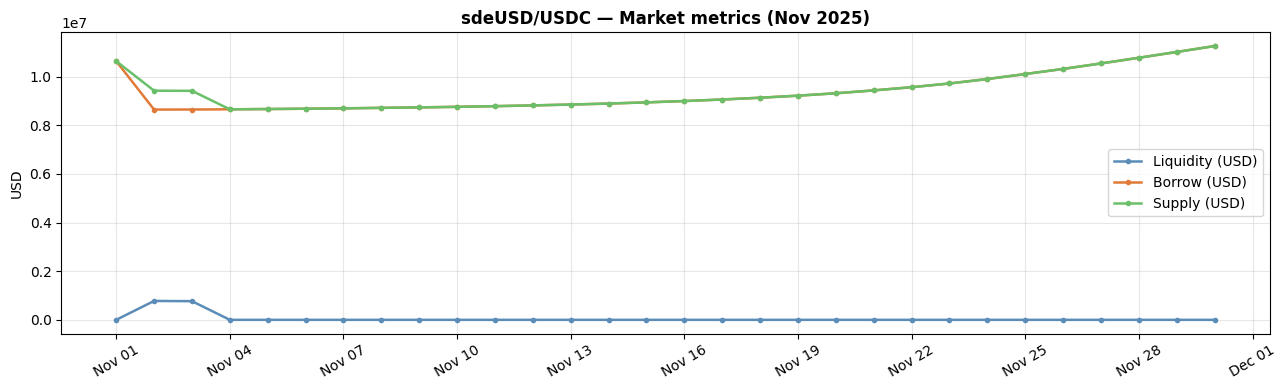

sdeUSD/USDC (0x0f9563442d64...)


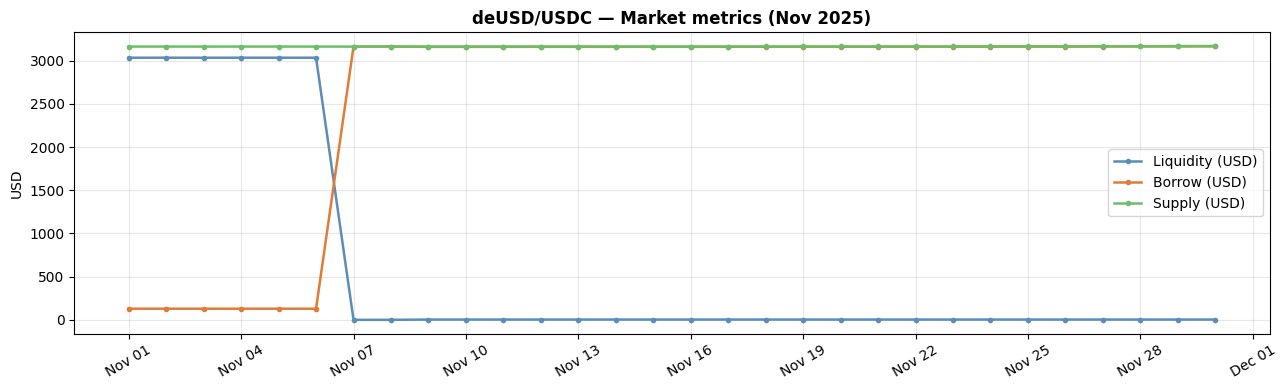

deUSD/USDC (0xbd1ad3b968f5...)


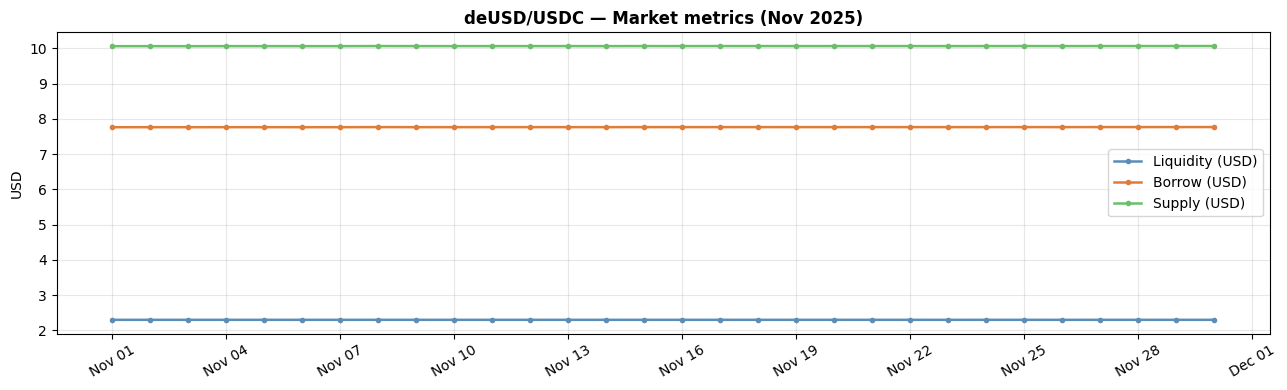

deUSD/USDC (0x7182fd5e9c6a...)


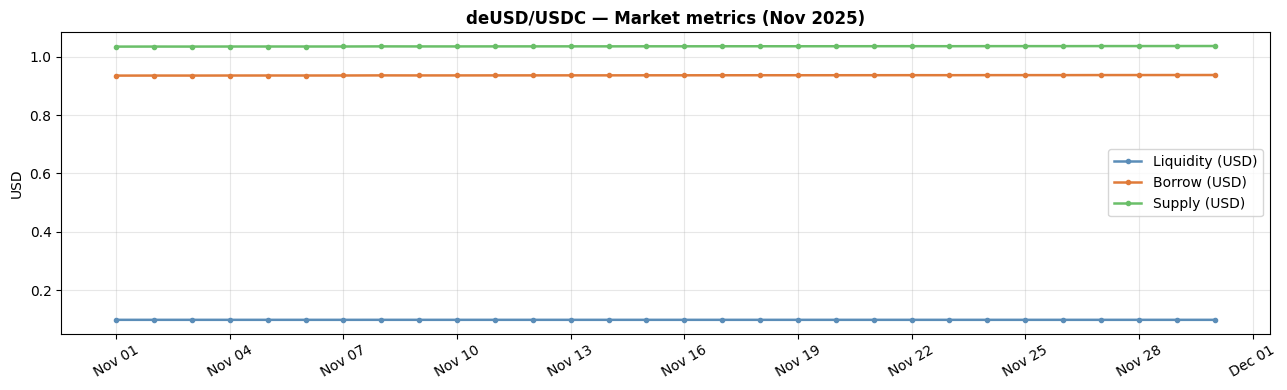

deUSD/USDC (0x1c6f0822b996...)


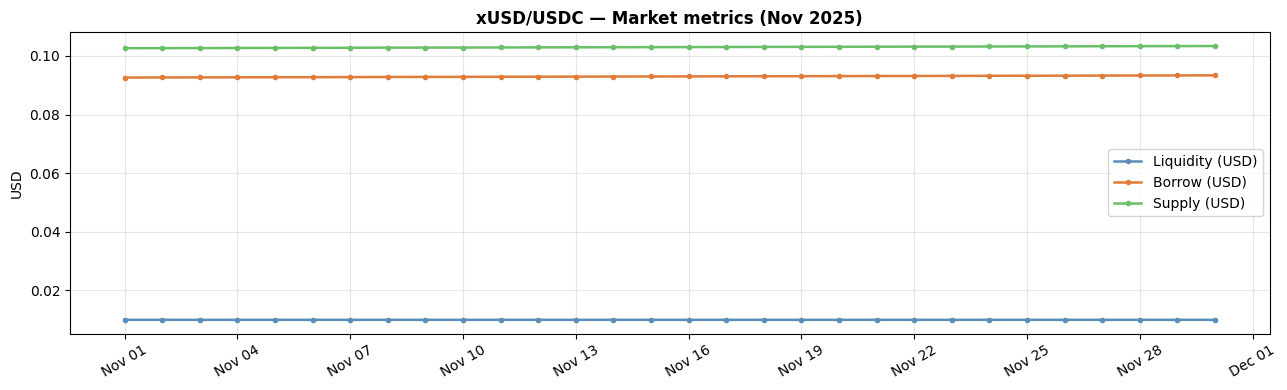

xUSD/USDC (0x39fe55e5102b...)


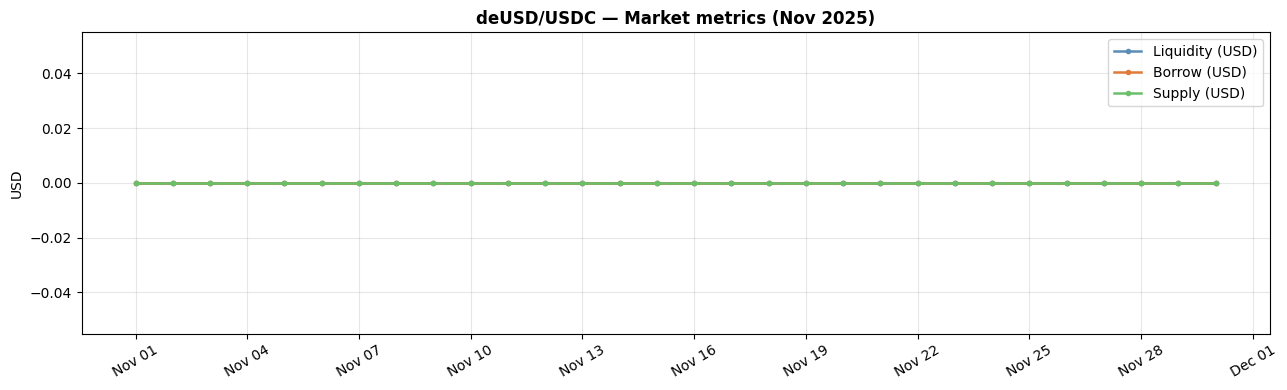

deUSD/USDC (0x226a59cd57c8...)


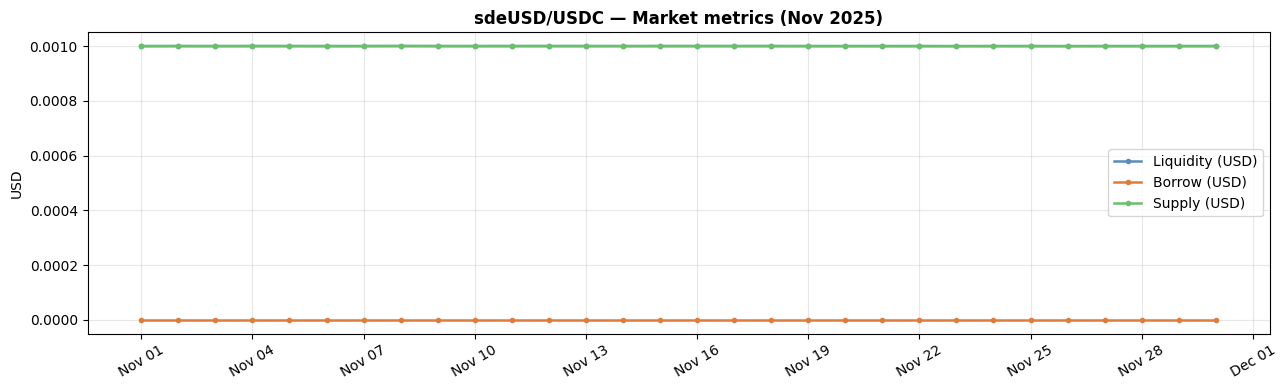

sdeUSD/USDC (0x46b46943e982...)


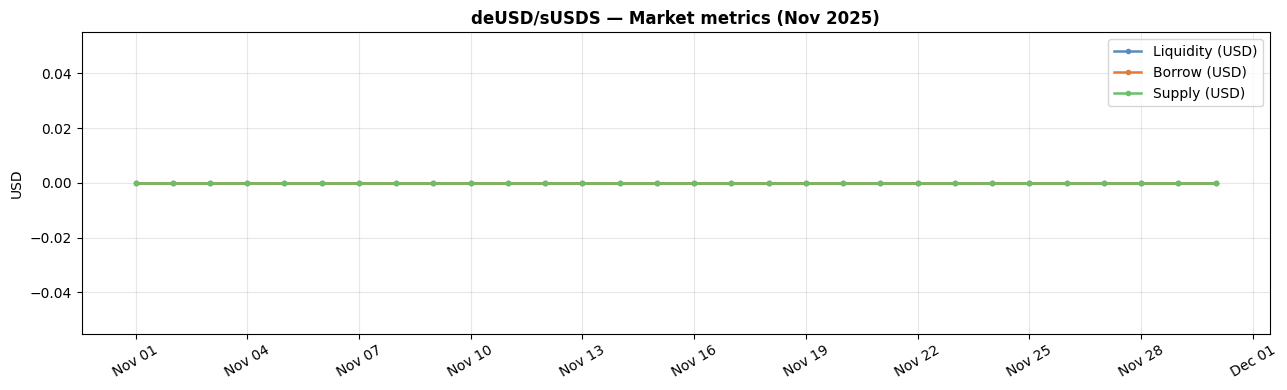

deUSD/sUSDS (0x7527be7772eb...)


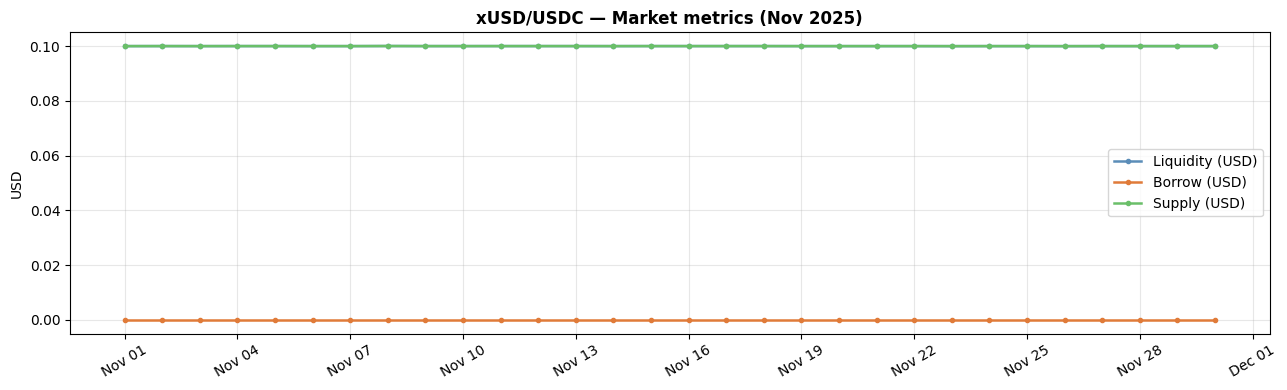

xUSD/USDC (0xc05394d0261e...)


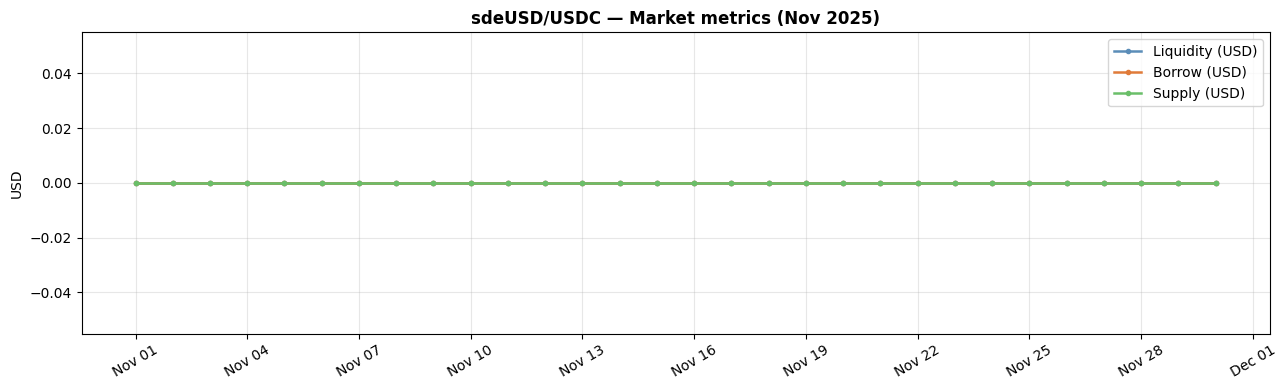

sdeUSD/USDC (0xe31af163f7ea...)


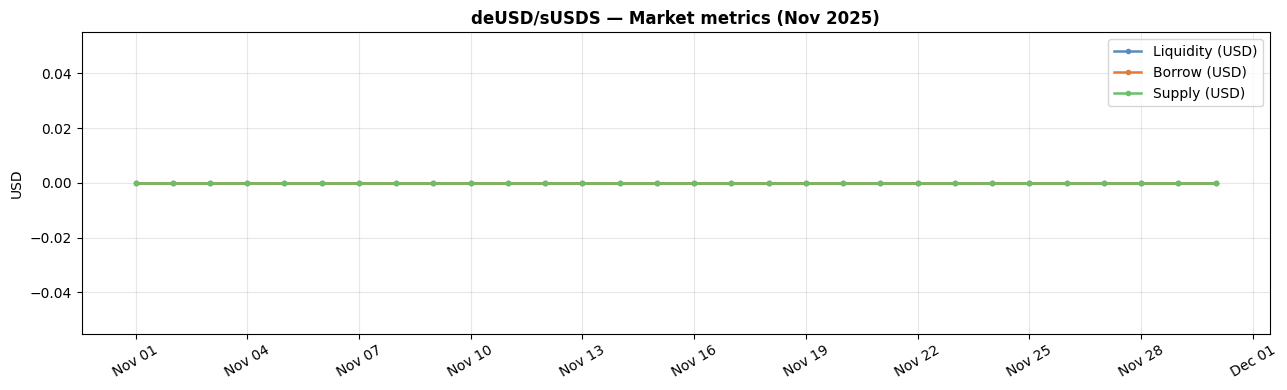

deUSD/sUSDS (0xeb0403429dab...)


In [19]:
# 4b — Market liquidity, borrow, supply over Nov 2025
FIELDS = {
    "liquidityAssetsUsd": ("Liquidity (USD)", "#5b8db8"),
    "borrowAssetsUsd":    ("Borrow (USD)",    "#e07b39"),
    "supplyAssetsUsd":    ("Supply (USD)",    "#6abf69"),
}

for m in hist_mkts:
    label = f"{m['collateralAsset']['symbol']}/{m['loanAsset']['symbol']}"
    uk_short = m["uniqueKey"][:14]+"..."

    fig, ax = plt.subplots(figsize=(13, 4))
    plotted = False
    for field, (name, color) in FIELDS.items():
        pts = m["historicalState"].get(field, [])
        df_f = xy_to_df(pts, name)
        if df_f.empty:
            continue
        df_f = df_f[(df_f["date"] >= NOV_START) & (df_f["date"] <= NOV_END)]
        if df_f.empty:
            continue
        ax.plot(df_f["date"], df_f[name], label=name, color=color, linewidth=1.8, marker="o", markersize=3)
        plotted = True

    if not plotted:
        plt.close()
        continue

    ax.set_title(f"{label} — Market metrics (Nov 2025)", fontweight="bold")
    ax.set_ylabel("USD")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"{label} ({uk_short})")


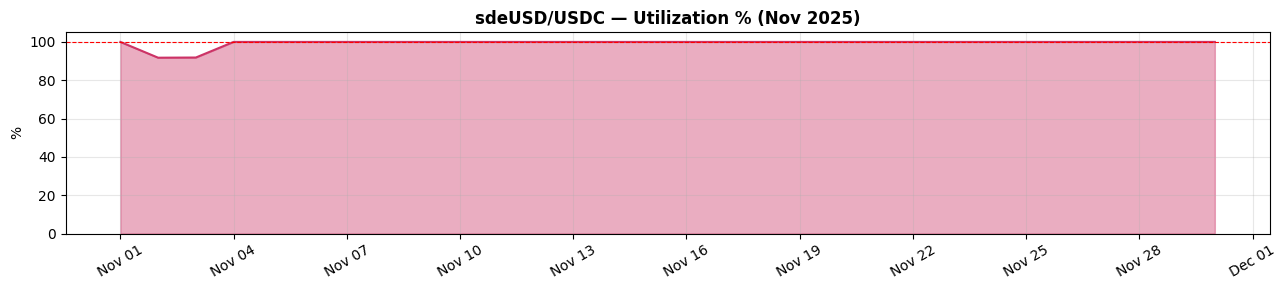

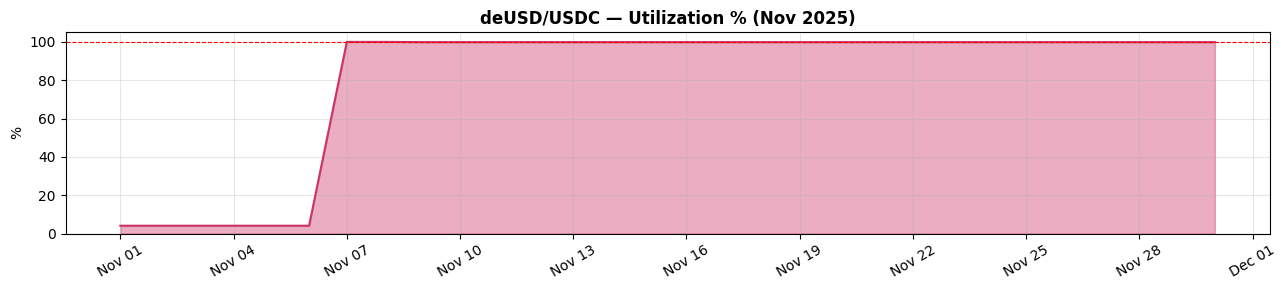

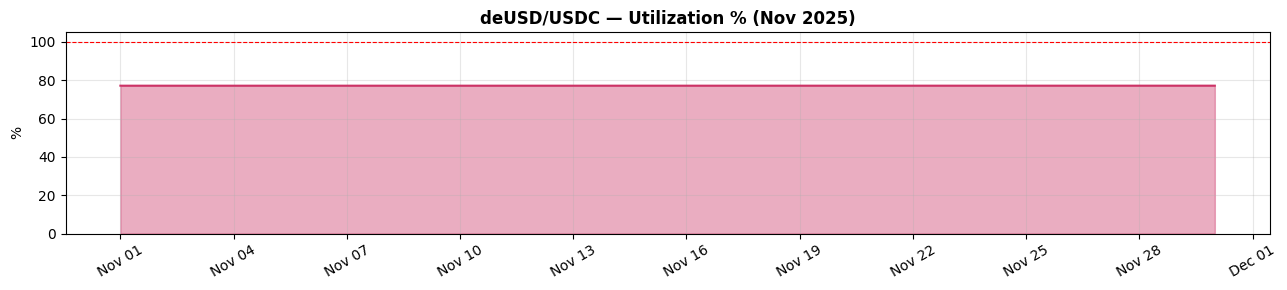

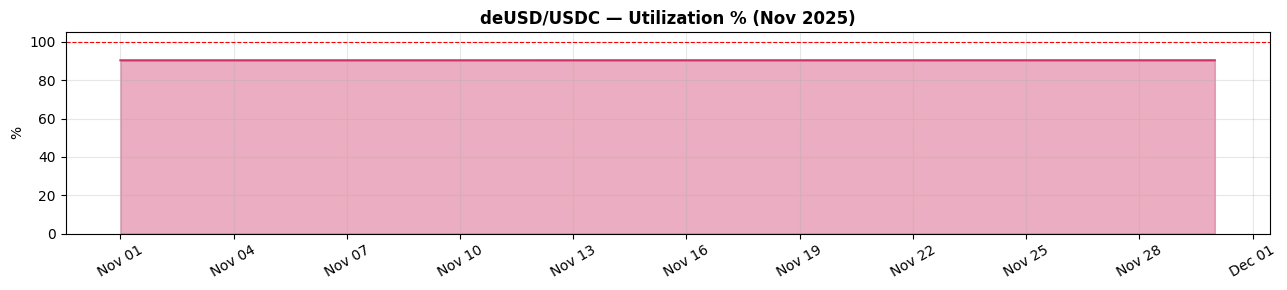

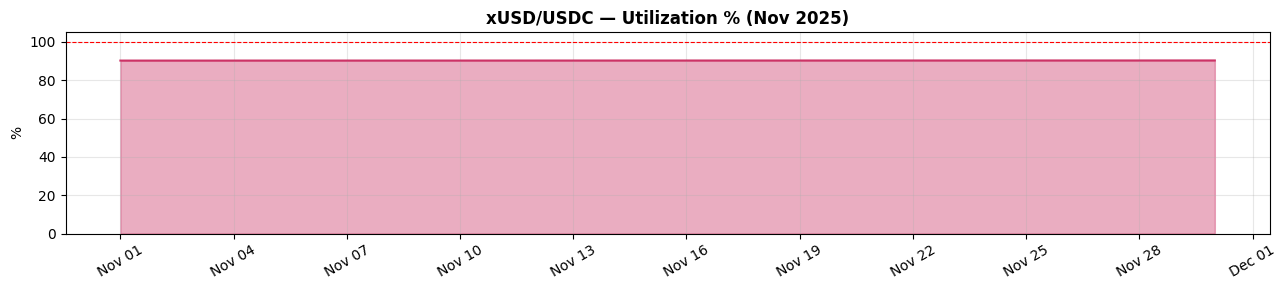

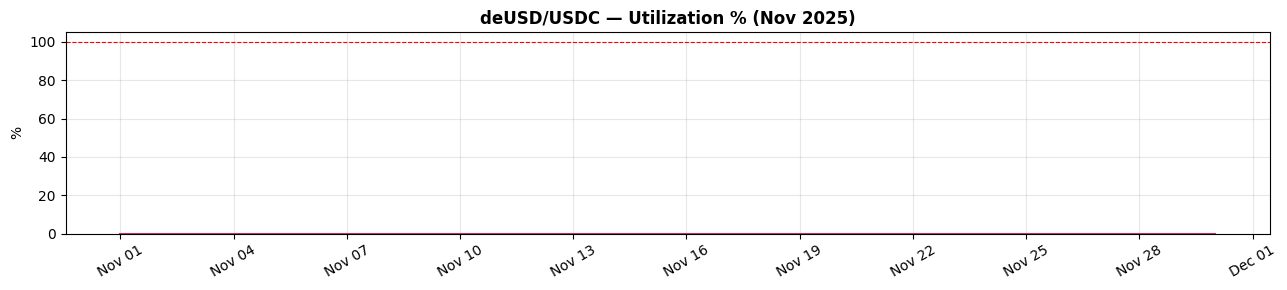

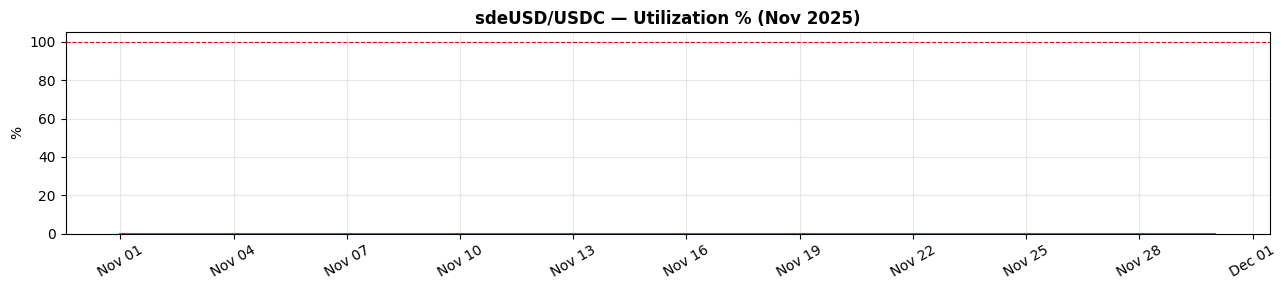

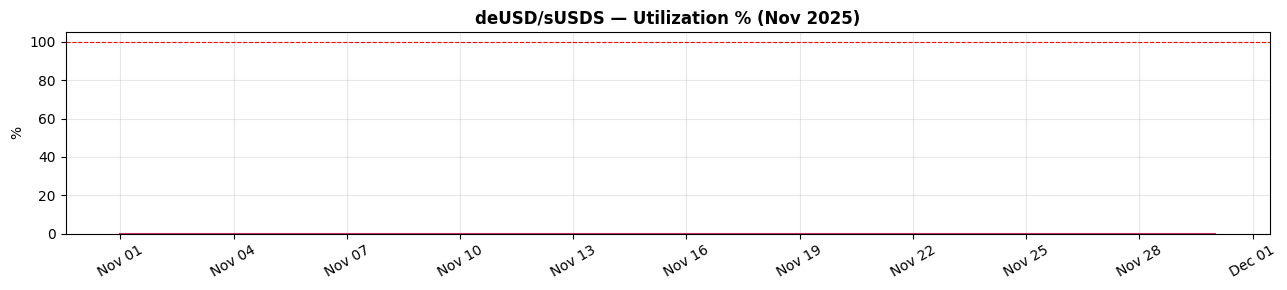

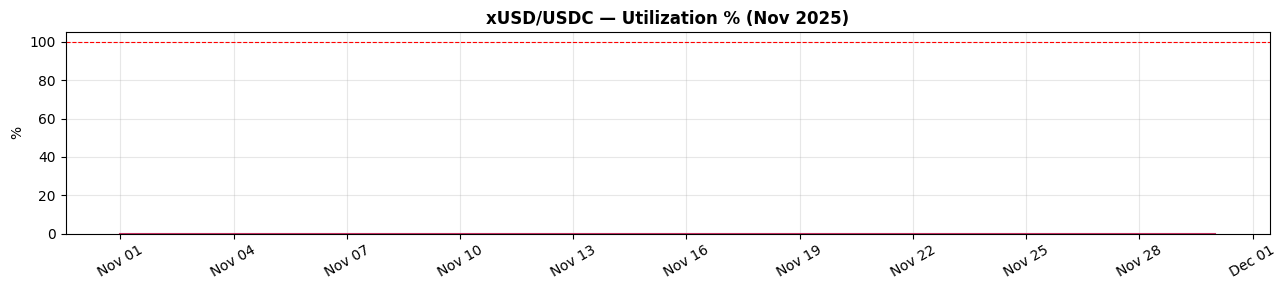

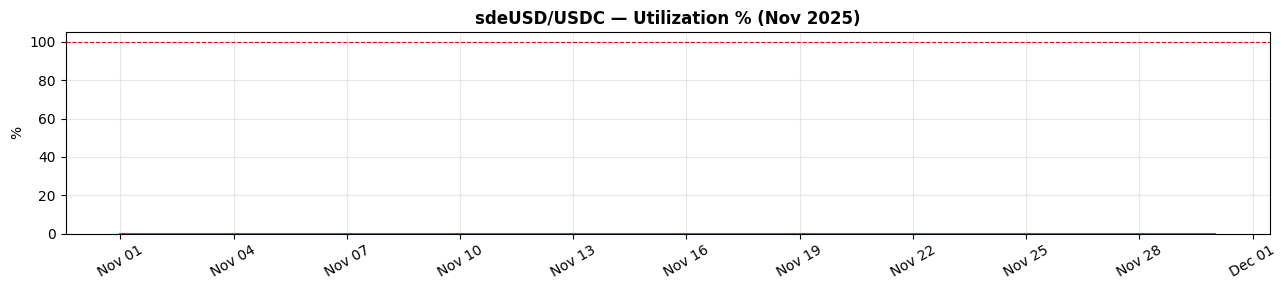

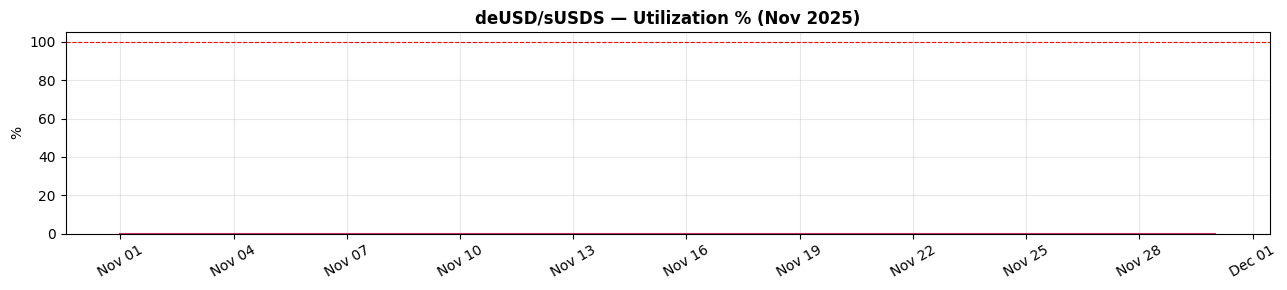

In [20]:
# 4c — Utilization timeline per market
for m in hist_mkts:
    label = f"{m['collateralAsset']['symbol']}/{m['loanAsset']['symbol']}"
    pts = m["historicalState"].get("utilization", [])
    df_u = xy_to_df(pts, "utilization")
    if df_u.empty:
        continue
    df_u = df_u[(df_u["date"] >= NOV_START) & (df_u["date"] <= NOV_END)]
    if df_u.empty:
        continue

    fig, ax = plt.subplots(figsize=(13, 3))
    ax.fill_between(df_u["date"], df_u["utilization"]*100, color="#c36", alpha=0.4)
    ax.plot(df_u["date"], df_u["utilization"]*100, color="#c36", linewidth=1.5)
    ax.axhline(100, color="red", linestyle="--", linewidth=0.8)
    ax.set_ylim(0, 105)
    ax.set_title(f"{label} — Utilization % (Nov 2025)", fontweight="bold")
    ax.set_ylabel("%")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


In [21]:
# 4d — Vault TVL & share price over the window
for v in hist_vaults:
    kind = v.get("vaultKind","?")
    name = v.get("name", v.get("address","?"))

    tvl_pts = v.get("historicalState",{}).get("totalAssetsUsd",[])
    df_tvl = xy_to_df(tvl_pts, "tvl_usd")
    df_tvl = df_tvl[(df_tvl["date"] >= NOV_START) & (df_tvl["date"] <= NOV_END)]

    sp_field = "sharePriceUsd" if kind=="v1" else "sharePrice"
    sp_pts = v.get("historicalState",{}).get(sp_field,[])
    df_sp = xy_to_df(sp_pts, "share_price")
    df_sp = df_sp[(df_sp["date"] >= NOV_START) & (df_sp["date"] <= NOV_END)]

    if df_tvl.empty and df_sp.empty:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    if not df_tvl.empty:
        axes[0].plot(df_tvl["date"], df_tvl["tvl_usd"], color="#5b8db8", linewidth=1.8, marker="o", markersize=3)
        axes[0].set_title(f"{name} — TVL (USD)")
        axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
        axes[0].xaxis.set_major_locator(mdates.DayLocator(interval=4))
        plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30)
        axes[0].grid(True, alpha=0.3)
    if not df_sp.empty:
        axes[1].plot(df_sp["date"], df_sp["share_price"], color="#6abf69", linewidth=1.8, marker="o", markersize=3)
        axes[1].set_title(f"{name} — Share price")
        axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
        axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=4))
        plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)
        axes[1].grid(True, alpha=0.3)

    fig.suptitle(f"[{kind.upper()}] {name}", fontweight="bold")
    plt.tight_layout()
    plt.show()


## 5 · Debrief: Why didn't liquidations work?

> *Core question: why were liquidations absent or negligible despite ~$130M borrow at 100% utilization with a severely depegged collateral?*


In [22]:
# 5a — State of the key market at the height of the incident
KEY_MARKET = "0x0f9563442d64ab3bd3bcb27058db0b0d4046a4c46f0acd811dacae9551d2b129"  # sdeUSD/USDC
km = next(m for m in markets if m["uniqueKey"]==KEY_MARKET)

lltv = float(km["lltv"]) / 1e18
borrow = km["state"]["borrowAssetsUsd"]
supply = km["state"]["supplyAssetsUsd"]
liquidity = km["state"]["liquidityAssetsUsd"]
util = km["state"]["utilization"]
warn_types = [w["type"] for w in km.get("warnings",[])]

print("=== Key market snapshot (sdeUSD / USDC) ===")
print(f"  LLTV:             {lltv*100:.1f}%")
print(f"  Borrow (USD):    ${borrow:>16,.2f}")
print(f"  Supply (USD):    ${supply:>16,.2f}")
print(f"  Liquidity (USD): ${liquidity:>16,.2f}")
print(f"  Utilization:     {util*100:.2f}%")
print(f"  Warnings:        {warn_types}")
print()
print("=== Hypothetical liquidation profitability ===")
# At 100% utilization, repaying any amount requires existing liquidity
# (which is $0). The liquidator must source USDC externally and flash-loan
# or have capital, but receives collateral that is worth close to $0.
# => no economic incentive to liquidate.
if borrow > 0:
    collateral_val_implied = km["state"].get("collateralAssetsUsd")  # null
    print(f"  Collateral USD on-chain:   {collateral_val_implied}  (oracle-priced null → depeg broke pricing)")
    print(f"  With $0 oracle price, seized collateral is worth $0 to any liquidator.")
    print(f"  With $0 liquidity in pool, a liquidator would need external USDC to repay.")
    print(f"  => No economic incentive; rational actors stay out.")


=== Key market snapshot (sdeUSD / USDC) ===
  LLTV:             91.5%
  Borrow (USD):    $  130,058,055.84
  Supply (USD):    $  130,058,055.84
  Liquidity (USD): $            0.00
  Utilization:     100.00%
  Warnings:        ['custom', 'no_whitelisted_allocation', 'not_whitelisted']

=== Hypothetical liquidation profitability ===
  Collateral USD on-chain:   None  (oracle-priced null → depeg broke pricing)
  With $0 oracle price, seized collateral is worth $0 to any liquidator.
  With $0 liquidity in pool, a liquidator would need external USDC to repay.
  => No economic incentive; rational actors stay out.


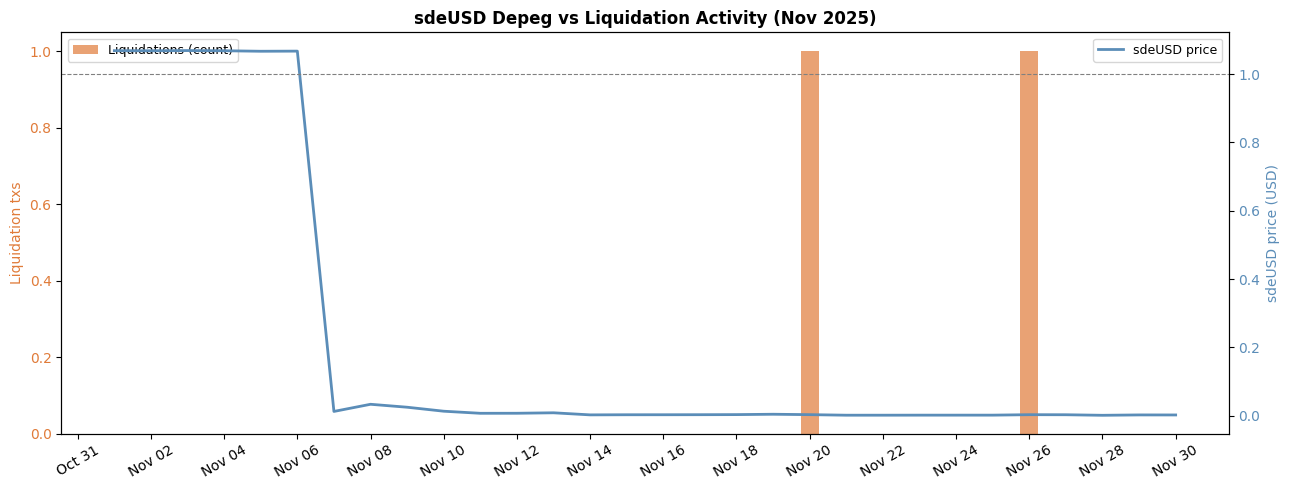

Note: sdeUSD price from Morpho oracle feed — sparse nulls indicate oracle staleness during depeg.


In [23]:
# 5b — Liquidations timeline vs price depeg
# Compare daily liq count with price to show the timing gap
liq_by_day = pd.DataFrame(
    [(d, c) for d, c in liq_summary.get("liquidationsPerDayUtc",{}).items()],
    columns=["day","liq_count"]
)
liq_by_day["day"] = pd.to_datetime(liq_by_day["day"])
liq_by_day = liq_by_day[(liq_by_day["day"] >= pd.Timestamp("2025-11-01")) & (liq_by_day["day"] <= pd.Timestamp("2025-11-30"))]

# price of sdeUSD (most relevant collateral)
sdeusd_price = next((s for s in prices if s["symbol"]=="sdeUSD"), None)
df_sdeprice = pd.DataFrame()
if sdeusd_price:
    df_sdeprice = xy_to_df(sdeusd_price["historicalPriceUsd"], "price_usd")
    df_sdeprice = df_sdeprice[(df_sdeprice["date"] >= pd.Timestamp(NOV_START)) &
                               (df_sdeprice["date"] <= pd.Timestamp(NOV_END))]

fig, ax1 = plt.subplots(figsize=(13, 5))
if not liq_by_day.empty:
    ax1.bar(liq_by_day["day"], liq_by_day["liq_count"], color="#e07b39", alpha=0.7, label="Liquidations (count)", width=0.5)
ax1.set_ylabel("Liquidation txs", color="#e07b39")
ax1.tick_params(axis="y", labelcolor="#e07b39")

if not df_sdeprice.empty:
    ax2 = ax1.twinx()
    ax2.plot(df_sdeprice["date"], df_sdeprice["price_usd"], color="#5b8db8", linewidth=2, label="sdeUSD price")
    ax2.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
    ax2.set_ylabel("sdeUSD price (USD)", color="#5b8db8")
    ax2.tick_params(axis="y", labelcolor="#5b8db8")
    ax2.legend(loc="upper right", fontsize=9)

ax1.set_title("sdeUSD Depeg vs Liquidation Activity (Nov 2025)", fontweight="bold")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30)
ax1.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()
print("Note: sdeUSD price from Morpho oracle feed — sparse nulls indicate oracle staleness during depeg.")


In [24]:
# 5c — Narrative bullets for debrief
print("""
=== WHY LIQUIDATIONS DIDN'T WORK — evidence summary ===

1. ORACLE STALENESS / BROKEN PRICING
   The Morpho oracle for sdeUSD/USDC returned null USD for collateral
   (collateralAssetsUsd = null in snapshot). If the oracle didn't mark
   collateral as underwater, Morpho's contract sees no unhealthy position.
   => No trigger for liquidation.

2. ZERO POOL LIQUIDITY
   liquidityAssetsUsd = $0 at 100% utilization.
   Liquidators receive the collateral but must source USDC externally.
   With collateral worth near $0 and no DEX depth to unwind sdeUSD,
   the trade is unprofitable regardless of oracle state.

3. NO WHITELISTED VAULT ALLOCATION
   warnings include 'no_whitelisted_allocation' (RED).
   No curator-managed vault was supplying to these markets —
   meaning the supply was from an isolated/direct counterparty,
   not from diversified vault depositors. Effectively a closed bilateral loop.

4. BAD DEBT WAS UNREALIZED
   The 'bad_debt_unrealized' warning is present on the deUSD/USDC market.
   Morpho isolates bad debt per market, but if the oracle never marks it,
   no liquidation bot can act.

5. SCALE vs. INCENTIVE
   The one borrower on sdeUSD/USDC holds ~$130M of the total.
   Liquidating requires flash-loaning $130M USDC to receive worthless sdeUSD.
   No rational arbitrageur takes that trade.
""")



=== WHY LIQUIDATIONS DIDN'T WORK — evidence summary ===

1. ORACLE STALENESS / BROKEN PRICING
   The Morpho oracle for sdeUSD/USDC returned null USD for collateral
   (collateralAssetsUsd = null in snapshot). If the oracle didn't mark
   collateral as underwater, Morpho's contract sees no unhealthy position.
   => No trigger for liquidation.

2. ZERO POOL LIQUIDITY
   liquidityAssetsUsd = $0 at 100% utilization.
   Liquidators receive the collateral but must source USDC externally.
   With collateral worth near $0 and no DEX depth to unwind sdeUSD,
   the trade is unprofitable regardless of oracle state.

3. NO WHITELISTED VAULT ALLOCATION
   warnings include 'no_whitelisted_allocation' (RED).
   No curator-managed vault was supplying to these markets —
   meaning the supply was from an isolated/direct counterparty,
   not from diversified vault depositors. Effectively a closed bilateral loop.

4. BAD DEBT WAS UNREALIZED
   The 'bad_debt_unrealized' warning is present on the deUSD/USD

## 6 · Debrief: Shared liquidity risk across isolated markets

> *"Markets are isolated, but liquidity risks are still shared" — what's your view?*


In [25]:
# 6a — Liquidity comparison: incident vs overall Morpho context
top5_tvl = sorted(v2_top, key=lambda v: v.get("totalAssetsUsd",0), reverse=True)[:5]
df_top5 = pd.DataFrame([{
    "name": v["name"],
    "tvl_usd_m": round(v["totalAssetsUsd"]/1e6, 2),
    "liquidity_usd_m": round(v["liquidityUsd"]/1e6, 2),
    "liquidity_%": round(v["liquidityUsd"]/v["totalAssetsUsd"]*100, 1) if v.get("totalAssetsUsd") else 0,
} for v in top5_tvl])

print("=== Top 5 Morpho V2 vaults by TVL (liquidity buffer reference) ===")
display(df_top5)

total_borrow_incident = df_mkts["borrow_usd"].sum()
print(f"\nTotal incident market borrow: ${total_borrow_incident:,.0f}")
print(f"Largest single vault TVL:     ${top5_tvl[0]['totalAssetsUsd']:,.0f}")


=== Top 5 Morpho V2 vaults by TVL (liquidity buffer reference) ===


,name,tvl_usd_m,liquidity_usd_m,liquidity_%
0,Sentora PYUSD Main,276.67,97.25,35.20
1,Sentora RLUSD Main,130.88,22.41,17.10



Total incident market borrow: $130,078,650
Largest single vault TVL:     $276,669,665


In [26]:
# 6b — Narrative: isolation vs shared liquidity argument
print("""
=== SHARED LIQUIDITY RISK — analysis framework ===

ISOLATION IS REAL at the market level:
  - Bad debt in the sdeUSD/USDC market cannot directly flow to the WETH/USDC market.
  - Morpho's accounting siloes each market's supply/borrow shares.

BUT liquidity risk is SHARED via two mechanisms:

(A) SHARED VAULT SUPPLY (if whitelisted)
    When a curator vault allocates across multiple markets, a crisis in one
    market can trigger mass withdrawals from the vault, which forces the
    vault to pull liquidity from OTHER markets to meet redemptions.
    Even healthy markets suffer liquidity drain from panicked depositors
    who cannot distinguish "I'm in the xUSD market" from "I'm in the vault."

(B) SYSTEMIC ORACLE / CONFIDENCE RISK
    A large depeg event on any prominent Morpho market damages the perception
    of protocol safety. Depositors in unrelated vaults may still withdraw,
    draining liquidity across the whole protocol simultaneously.
    This is a shared *confidence* externality, even without shared accounting.

(C) THIS CASE: no whitelisted vaults → risk NOT shared
    Because no curator vault allocated to xUSD/deUSD/sdeUSD markets,
    the supply was isolated bilateral (direct borrowers).
    BUT: the $130M bad debt still sat on-chain labeled "Morpho," creating
    reputational spillover that could pressure other vault depositors.

VERDICT: Morpho's isolation prevents *accounting* contagion but not
*liquidity* contagion when vaults span multiple markets.
For incident markets with zero vault allocation, isolation held mechanically
but systemic reputational risk remained.
""")



=== SHARED LIQUIDITY RISK — analysis framework ===

ISOLATION IS REAL at the market level:
  - Bad debt in the sdeUSD/USDC market cannot directly flow to the WETH/USDC market.
  - Morpho's accounting siloes each market's supply/borrow shares.

BUT liquidity risk is SHARED via two mechanisms:

(A) SHARED VAULT SUPPLY (if whitelisted)
    When a curator vault allocates across multiple markets, a crisis in one
    market can trigger mass withdrawals from the vault, which forces the
    vault to pull liquidity from OTHER markets to meet redemptions.
    Even healthy markets suffer liquidity drain from panicked depositors
    who cannot distinguish "I'm in the xUSD market" from "I'm in the vault."

(B) SYSTEMIC ORACLE / CONFIDENCE RISK
    A large depeg event on any prominent Morpho market damages the perception
    of protocol safety. Depositors in unrelated vaults may still withdraw,
    draining liquidity across the whole protocol simultaneously.
    This is a shared *confidence* extern